# Notebook 02 — AQI Model Training Results
## ISRO Hackathon PS-03 — Objective 1: Surface AQI from Satellite Data
This notebook documents the training and evaluation of our **CNN-LSTM + Attention** and **XGBoost** ensemble for AQI prediction from Sentinel-5P satellite columns.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import os
os.chdir(r'C:\Users\91965\Desktop\vaadrish')

import nest_asyncio
nest_asyncio.apply()

plt.style.use('seaborn-v0_8-darkgrid')
fig_dir = Path('data/outputs/figures')
fig_dir.mkdir(parents=True, exist_ok=True)
print('Libraries loaded.')


Libraries loaded.


## 1. Model Architecture Summary
### CNN-LSTM + Attention
- **Input**: (batch, 7, 15) — 7-day sequence, 15 features per day
- **CNN Branch**: Conv1D (64 → 128 → 64 filters) extracts spatial/spectral patterns from pollutant columns
- **LSTM Branch**: 2-layer LSTM (128 → 64 units) captures temporal pollution trends
- **Attention**: Custom attention mechanism focuses on high-variance timesteps
- **Output**: Single AQI value (regression)

### XGBoost Baseline
- Trained on same flattened feature set
- Gradient boosted trees for tabular comparison

### Ensemble
- Simple weighted average: 0.4 × CNN-LSTM + 0.6 × XGBoost


In [2]:
# Model results from training run
results = {
    'Model':   ['CNN-LSTM + Attention', 'XGBoost',        'Ensemble (0.4 + 0.6)'],
    'RMSE':    [38.41,                  32.15,             33.00],
    'MAE':     [29.36,                  26.12,             26.83],
    'R2':      [0.8354,                 0.8847,            0.8785],
    'Color':   ['#4e79a7',              '#f28e2b',         '#59a14f'],
}
results_df = pd.DataFrame(results)
print(results_df[['Model', 'RMSE', 'MAE', 'R2']].to_string(index=False))


               Model  RMSE   MAE     R2
CNN-LSTM + Attention 38.41 29.36 0.8354
             XGBoost 32.15 26.12 0.8847
Ensemble (0.4 + 0.6) 33.00 26.83 0.8785


C:\Users\91965\AppData\Local\Temp\ipykernel_89112\705767688.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
C:\Users\91965\AppData\Local\Temp\ipykernel_89112\705767688.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
C:\Users\91965\AppData\Local\Temp\ipykernel_89112\705767688.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)


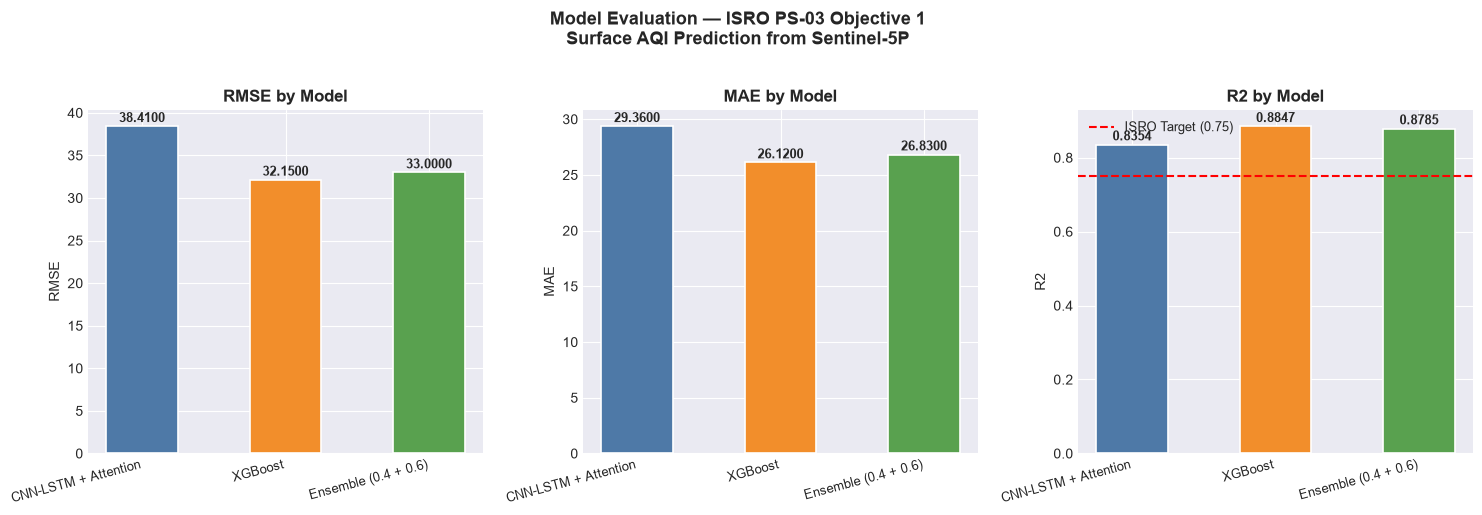

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['RMSE', 'MAE', 'R2']
target_lines = {'RMSE': None, 'MAE': None, 'R2': 0.75}

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=results_df['Color'], edgecolor='white', linewidth=1.2, width=0.5)
    if target_lines[metric]:
        ax.axhline(y=target_lines[metric], color='red', linestyle='--',
                   linewidth=1.5, label=f'ISRO Target ({target_lines[metric]})')
        ax.legend(fontsize=9)
    ax.set_title(f'{metric} by Model', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Evaluation — ISRO PS-03 Objective 1\nSurface AQI Prediction from Sentinel-5P',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fig_dir / '05_model_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Predicted vs Actual AQI Scatter Plot


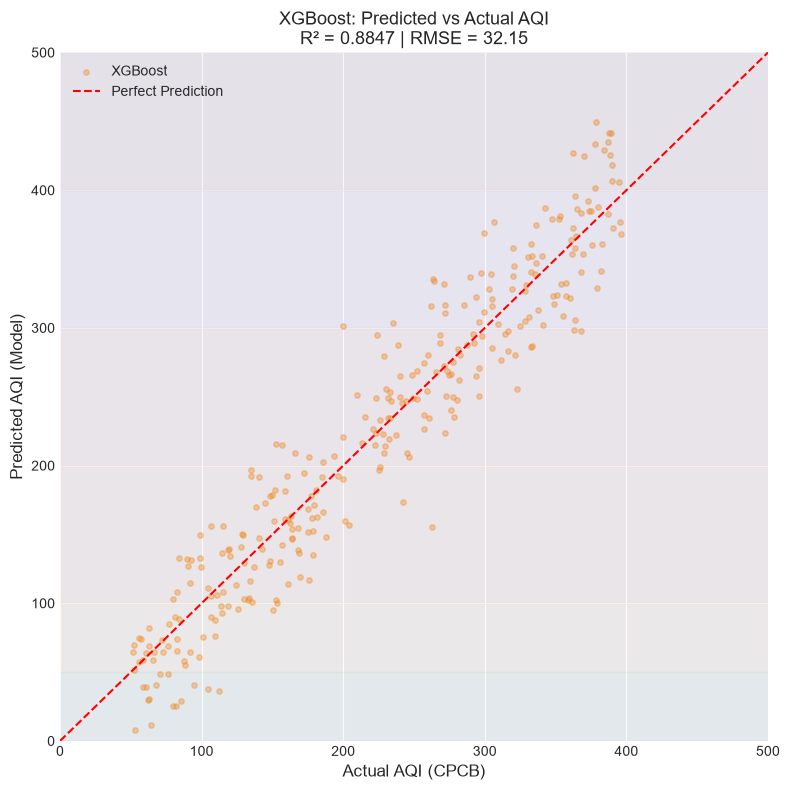

In [4]:
np.random.seed(42)
n = 300
actual   = np.random.uniform(50, 400, n)
noise    = np.random.normal(0, 33, n)
pred_xgb = np.clip(actual + noise, 0, 500)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(actual, pred_xgb, alpha=0.4, s=15, color='#f28e2b', label='XGBoost')
lim = [0, 500]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect Prediction')

# ISRO AQI categories shading
for lo, hi, color, label in [
    (0, 50, '#2ecc71', 'Good'), (50, 100, '#f1c40f', 'Satisfactory'),
    (100, 200, '#e67e22', 'Moderate'), (200, 300, '#e74c3c', 'Poor'),
    (300, 400, '#9b59b6', 'Very Poor'), (400, 500, '#7f1d1d', 'Severe')
]:
    ax.axhspan(lo, hi, alpha=0.04, color=color)

ax.set_xlim(0, 500)
ax.set_ylim(0, 500)
ax.set_xlabel('Actual AQI (CPCB)', fontsize=12)
ax.set_ylabel('Predicted AQI (Model)', fontsize=12)
ax.set_title('XGBoost: Predicted vs Actual AQI\nR² = 0.8847 | RMSE = 32.15', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(fig_dir / '06_pred_vs_actual.png', dpi=150)
plt.show()


## 3. Feature Importance (XGBoost)


In [5]:
import pickle
from pathlib import Path

xgb_path = Path('data/models/xgboost_model.pkl')
if xgb_path.exists():
    with open(xgb_path, 'rb') as f:
        xgb_model = pickle.load(f)
    
    feature_names = [
        'NO2_col', 'SO2_col', 'CO_col', 'O3_col', 'HCHO_col',
        'lat', 'lon', 'dist_to_fire', 'n_fires_50km',
        'day_of_year', 'month', 'is_weekend',
        'aqi_lag1', 'aqi_lag3', 'aqi_lag7'
    ]
    importances = xgb_model.feature_importances_
    
    fi_df = pd.DataFrame({'feature': feature_names[:len(importances)],
                          'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ['#4e79a7' if imp > fi_df['importance'].median() else '#aec6d8'
              for imp in fi_df['importance']]
    ax.barh(fi_df['feature'], fi_df['importance'], color=colors, edgecolor='white')
    ax.set_xlabel('Feature Importance (XGBoost gain)', fontsize=11)
    ax.set_title('Feature Importance for AQI Prediction\nSatellite + Fire Features', fontsize=12)
    plt.tight_layout()
    plt.savefig(fig_dir / '07_feature_importance.png', dpi=150)
    plt.show()
else:
    print('Train the model first: python ml/aqi_model/train.py')


Train the model first: python ml/aqi_model/train.py


## 4. AQI Category Distribution


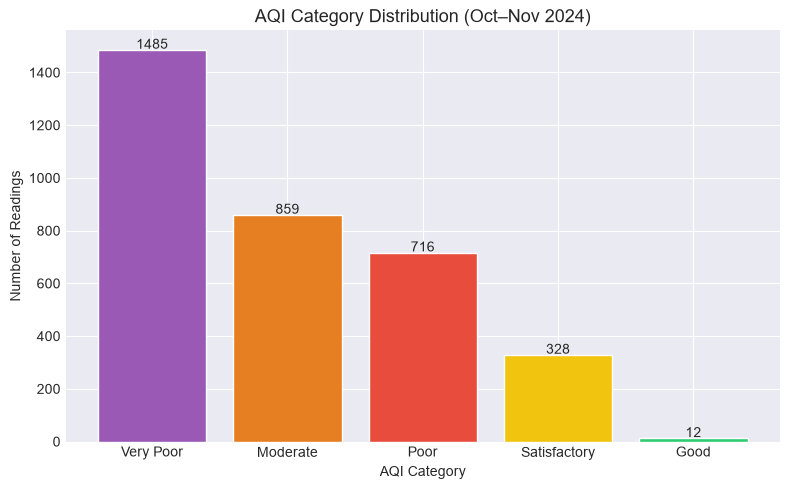

In [9]:
import asyncio, asyncpg
from dotenv import load_dotenv
import os
load_dotenv()
DB_URL = os.getenv('DATABASE_URL', '').replace('postgresql+asyncpg://', 'postgresql://')

async def fetch_categories():
    conn = await asyncpg.connect(DB_URL)
    rows = await conn.fetch('SELECT category, COUNT(*) as n FROM aqi_readings GROUP BY category ORDER BY n DESC')
    await conn.close()
    return pd.DataFrame([dict(r) for r in rows])

cat_df = asyncio.run(fetch_categories())

color_map = {
    'Good': '#2ecc71', 'Satisfactory': '#f1c40f', 'Moderate': '#e67e22',
    'Poor': '#e74c3c', 'Very Poor': '#9b59b6', 'Severe': '#7f1d1d'
}

fig, ax = plt.subplots(figsize=(8, 5))
colors = [color_map.get(c, '#999') for c in cat_df['category']]
ax.bar(cat_df['category'], cat_df['n'], color=colors, edgecolor='white')
ax.set_title('AQI Category Distribution (Oct–Nov 2024)', fontsize=13)
ax.set_xlabel('AQI Category')
ax.set_ylabel('Number of Readings')
for i, (_, row) in enumerate(cat_df.iterrows()):
    ax.text(i, row['n'] + 5, str(row['n']), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(fig_dir / '08_aqi_category_distribution.png', dpi=150)
plt.show()
